In [ ]:
import random
import math
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statistics import mean
from functools import reduce
from itertools import combinations
from copy import deepcopy
from scipy.optimize import minimize

Consts and Setup

In [2]:
eps = 1.0e-14
N = 4
M = 10
seed = 42

In [3]:
random.seed(seed)
sns.set_theme(style="whitegrid")

The Heart of Darkness

In [ ]:
class DifferentialEvolution:
    def __init__(self,
                 objective_function,
                 constraint_functions,
                 upper_bounds,
                 lower_bounds,
                 population_size):
        self.objective_function = objective_function
        self.constraint_functions = constraint_functions
        self.upper_bounds = upper_bounds
        self.lower_bounds = lower_bounds
        self.population_size = population_size

    def run(self,
            stopping_condition,
            crossover,
            selection_mutation):
        self.initialize_stats()

        population = [[self.new_chromosome(upper, lower) for upper, lower in zip(self.upper_bounds, self.lower_bounds)] for _ in range(self.population_size)]
        scores = [self.evaluate(x) for x in population]
        self.update_stats(population, scores)

        while stopping_condition.check(self):
            new_generation = []
            new_scores = []

            for x, s in zip(population, scores):
                u = crossover.do(x)
                v = selection_mutation.do(x,
                                          population,
                                          self.best_solution_hist[-1],
                                          u)
                v = self.enforce_bounds(v)
                f = self.evaluate(v)

                if f < s:
                    new_generation.append(v)
                    new_scores.append(f)
                else:
                    new_generation.append(x)
                    new_scores.append(s)

            population = new_generation
            scores = new_scores
            self.iter_count += 1
            self.update_stats(population, scores)
        
        return self

    def initialize_stats(self):
        self.iter_count = 0
        self.eval_count = 0
        self.best_solution_hist = []
        self.best_score_hist = []
        self.population_diversity_hist = []

    def update_stats(self, population, scores):
        best_idx = scores.index(min(scores))

        self.best_solution_hist.append(population[best_idx])
        self.best_score_hist.append(scores[best_idx])
        self.population_diversity_hist.append(self.diversity(population))

    def new_chromosome(self, upper, lower):
        return random.uniform(lower, upper)
    
    def enforce_bounds(self, x):
        return [a if lower<=a and a<=upper else self.new_chromosome(upper, lower) for a, upper, lower in zip(x, self.upper_bounds, self.lower_bounds)]
    
    def evaluate(self, x):
        self.eval_count += 1

        cs = [cf(x) for cf in self.constraint_functions]
        cs = [c if eps < c else 1 for c in cs]

        return self.objective_function(x) * reduce(lambda x, y: x * y, cs)

    def diversity(self, population):
        n = self.population_size
        total_dist = 0
        
        for a, b in combinations(population, r=2):
            total_dist += math.sqrt(sum([(x - y)**2 for x, y in zip(a, b)]))

        return total_dist/(n*(n-1)/2)

Stopping Conditions

In [5]:
class MaxIterationsStop:
    def __init__(self,
                 max_iterations):
        self.max_iterations = max_iterations
    
    def check(self, record):
        return record.iter_count < self.max_iterations

In [6]:
class FitnessThresholdStop:
    def __init__(self,
                 fitness_threshold):
        self.fitness_threshold = fitness_threshold
    
    def check(self, record):
        return self.fitness_threshold < record.best_score_hist[-1]

In [7]:
class NoImprovementStop:
    def __init__(self,
                 max_no_improve_iters,
                 no_improve_threshold):
        self.max_no_improve_iters = max_no_improve_iters
        self.no_improve_threshold = no_improve_threshold
    
    def check(self, record):
        if self.max_no_improve_iters < record.iter_count:
            window = record.best_score_hist[-self.max_no_improve_iters:]
            improves = [abs(b - a) for a, b in zip(window[:-1], window[1:])]
            return not all([imp < self.no_improve_threshold for imp in improves])
        return True

Crossovers

In [8]:
class Crossover:
    def __init__(self, p):
        self.p = p
    
    def do(self, x):
        d = random.randrange(len(x))
        u = [self.p < random.random() for _ in x]
        u[d] = True

        return u

In [9]:
class CrossoverSA:
    def do(self, x):
        d = random.randrange(len(x))
        u = [random.random() < random.gauss(0.5, 0.15) for _ in x]
        u[d] = True

        return u

Selections and Mutations

In [10]:
class SelectMutateRand1:
    def __init__(self,
                 omega):
        self.omega = omega

    def do(self,
           xx,
           population,
           _,
           uu):
        aa, bb, cc = random.sample(population, 3)

        return [a + self.omega*(b - c) if u else x for a, b, c, u, x in zip(aa, bb, cc, uu, xx)]

In [11]:
class SelectMutateBest2:
    def __init__(self,
                 nu,
                 omega):
        self.nu = nu
        self.omega = omega

    def do(self,
           xx,
           population,
           best,
           uu):
        aa, bb, cc, dd = random.sample(population, 4)

        return [bst + self.nu*(a - b) + self.omega*(c - d) if u else x for a, b, c, d, u, x, bst in zip(aa, bb, cc, dd, uu, xx, best)]
        

In [12]:
class SelectMutateSDE:
    def __init__(self,
                 dimension):
        self.omegas = [random.gauss(0.5, 0.15) for _ in range(dimension)]
    
    def do(self,
           xx,
           population,
           _,
           uu):
        self.omegas = [self.__evolve_omega() for _ in self.omegas]
        aa, bb, cc = random.sample(population, 3)

        return [a + o*(b - c) if u else x for a, b, c, o, u, x in zip(aa, bb, cc, self.omegas, uu, xx)]

    def __evolve_omega(self):
        o1, o2, o3 = random.sample(self.omegas, 3)

        return o1 + random.gauss(0, 0.5)*(o2 - o3)

Test Functions

In [13]:
class Sphere:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum([x**2 for x in xx])

In [14]:
class Rosenbrock:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum([100*(x1**2-x2)**2+(1-x1)**2 for x1, x2 in zip(xx[:-1], xx[1:])])

In [15]:
class Step:
    upper_bounds = [5.12 for _ in range(N)]
    lower_bounds = [-5.12 for _ in range(N)]

    def fun(xx):
        return sum([math.floor(x) for x in xx])

In [16]:
class Griewank:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return 1 + sum([x**2 for x in xx])/4000 - reduce(lambda x, y: x*y, [math.cos(x/math.sqrt(i+1)) for i, x in enumerate(xx)])

In [17]:
class StyblinskiTang:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    def fun(xx):
        return sum([x**4-16*x**2+5*x for x in xx])/2

In [18]:
class Shekel:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    A = [[random.uniform(-M, M) for _ in range(M)] for _ in range(N)]
    C = [random.uniform(-M, M) for _ in range(M)]

    def fun(xx):
        return -sum([1 / (sum([(xx[j] - Shekel.A[j][i])**2 for j in range(N)]) + Shekel.C[i]) for i in range(N+2)])

In [19]:
class Rastrigin:
    upper_bounds = [5.12 for _ in range(N)]
    lower_bounds = [-5.12 for _ in range(N)]

    def fun(xx):
        return sum([x**2-10*math.cos(2*math.pi*x)+10 for x in xx])

In [20]:
class Ackley:
    upper_bounds = [5 for _ in range(N)]
    lower_bounds = [-5 for _ in range(N)]

    def fun(xx):
        return -20*math.exp(-0.2*math.sqrt(mean([x**2 for x in xx])))-math.exp(mean([math.cos(2*math.pi*x) for x in xx]))+math.e+20

In [21]:
class RotatedElipsoid:
    upper_bounds = [2**M for _ in range(N)]
    lower_bounds = [-2**M for _ in range(N)]

    def fun(xx):
        return sum(((i+1)*x)**2 for i, x in enumerate(xx))

In [ ]:
class KeaneBump:
    upper_bounds = [10 for _ in range(N)]
    lower_bounds = [0 for _ in range(N)]

    def constraint_1(xx):
        c1 = 0.75 - reduce(lambda x, y: x*y, xx)
        return 1 if c1 < 0 else c1*75
    
    def constraint_2(xx):
        c2 = sum(xx) - 7.5*len(xx)
        return 1 if c2 < 0 else c2*75

    def fun(xx):
        cos_x_4 = sum([math.cos(x)**4 for x in xx])
        cos_x_2_prod = reduce(lambda x, y: x * y, [math.cos(x)**2 for x in xx])
        numerator = -abs(cos_x_4 - 2 * cos_x_2_prod)
        denominator = math.sqrt(sum((i + 1) * xx[i]**2 for i in range(len(xx))))
        if denominator == 0:
            return sys.float_info.max
        return numerator / denominator

Visualizer

In [ ]:
class Visualizer:
    def __init__(self,
                 records,
                 names,
                 plate):
        self.data = pd.DataFrame({
            'Generation': reduce(lambda x, y: x + y, [list(range(len(r.best_score_hist))) for r in records], []),
            'Fitness Score': reduce(lambda x, y: x + y, [r.best_score_hist for r in records], []),
            'Population Diversity': reduce(lambda x, y: x + y, [r.population_diversity_hist for r in records], []),
            'Algorithm': reduce(lambda x, y: x + y, [[n]*len(r.best_score_hist) for n, r in zip(names, records)], [])
        })
        self.plate = plate
    
    def plot_fitness_evolution(self):
        plt.figure(figsize=(10,6))

        sns.lineplot(data=self.data,
                     x='Generation',
                     y='Fitness Score',
                     hue='Algorithm',
                     dashes=False)
        
        plt.title('Fitness Evolution of Optimization Algorithms')
        plt.xlabel('Generation (Iteration)')
        plt.ylabel('Best Fitness Score (Lower is Better)')

        plt.tight_layout()
        # plt.show()
        plt.savefig(f'FitnessScore{self.plate}.png', dpi=300)

    def plot_population_diversity(self):
        plt.figure(figsize=(10,6))

        sns.lineplot(data=self.data,
                     x='Generation',
                     y='Population Diversity',
                     hue='Algorithm',
                     dashes=False)
        
        plt.title('Population Diversity of Optimization Algorithms')
        plt.xlabel('Generation (Iteration)')
        plt.ylabel('Population Diversity')

        plt.tight_layout()
        # plt.show()
        plt.savefig(f'PopulationDiversity{self.plate}.png', dpi=300)


Benchmark Testbed

In [ ]:
class TestBed:
    def __init__(self):
        self.tests = [Sphere, Rosenbrock, Step, Griewank, StyblinskiTang,
                      Shekel, Rastrigin, Ackley, RotatedElipsoid]
        
        self.optimizers = []
        for test in self.tests:
            self.optimizers.append(DifferentialEvolution(test.fun,
                                                         [lambda _: 1],
                                                         test.upper_bounds,
                                                         test.lower_bounds,
                                                         20*N))
        self.optimizers.append(DifferentialEvolution(KeaneBump.fun,
                                                     [KeaneBump.constraint_1, KeaneBump.constraint_2],
                                                     KeaneBump.upper_bounds,
                                                     KeaneBump.lower_bounds,
                                                     20*N))
    
    def run_display(self):
        iterations = 2048
        for i, optimizer in enumerate(self.optimizers):
            de_rand_1 = optimizer.run(MaxIterationsStop(iterations),
                                      Crossover(0.1),
                                      SelectMutateRand1(0.8))
            de_best_2 = optimizer.run(MaxIterationsStop(iterations),
                                      Crossover(0.1),
                                      SelectMutateBest2(0.6, 0.6))
            sde = optimizer.run(MaxIterationsStop(iterations),
                                CrossoverSA(),
                                SelectMutateSDE())
            print(f'DE/rand/1 found minimum {de_rand_1.objective_function(de_rand_1.best_solution_hist[-1])} of {self.tests[i].__name__}')
            print(f'DE/best/2 found minimum {de_best_2.objective_function(de_best_2.best_solution_hist[-1])} of {self.tests[i].__name__}')
            print(f'SDE found minimum {sde.objective_function(sde.best_solution_hist[-1])} of {self.tests[i].__name__}')
            v = Visualizer([de_rand_1, de_best_2, sde],
                           ['DE/rand/1', 'DE/best/2', 'SDE'],
                           i)
            v.plot_fitness_evolution()
            v.plot_population_diversity()

DE/rand/1 found minimum 21956.722183325444 of Sphere
DE/best/2 found minimum 21956.722183325444 of Sphere
SDE found minimum 21956.722183325444 of Sphere
data 6147 6147 6147 6147
DE/rand/1 found minimum 158971395285.5967 of Rosenbrock
DE/best/2 found minimum 158971395285.5967 of Rosenbrock
SDE found minimum 158971395285.5967 of Rosenbrock
data 6147 6147 6147 6147
DE/rand/1 found minimum -17 of Step
DE/best/2 found minimum -17 of Step
SDE found minimum -17 of Step
data 6147 6147 6147 6147
DE/rand/1 found minimum 28.90340936637637 of Griewank
DE/best/2 found minimum 28.90340936637637 of Griewank
SDE found minimum 28.90340936637637 of Griewank
data 6147 6147 6147 6147
DE/rand/1 found minimum -126.11253700519768 of StyblinskiTang
DE/best/2 found minimum -126.11253700519768 of StyblinskiTang
SDE found minimum -126.11253700519768 of StyblinskiTang
data 6147 6147 6147 6147
DE/rand/1 found minimum -1.6521897068507592 of Shekel
DE/best/2 found minimum -1.6521897068507592 of Shekel
SDE found mini

TypeError: unsupported operand type(s) for -: 'list' and 'float'

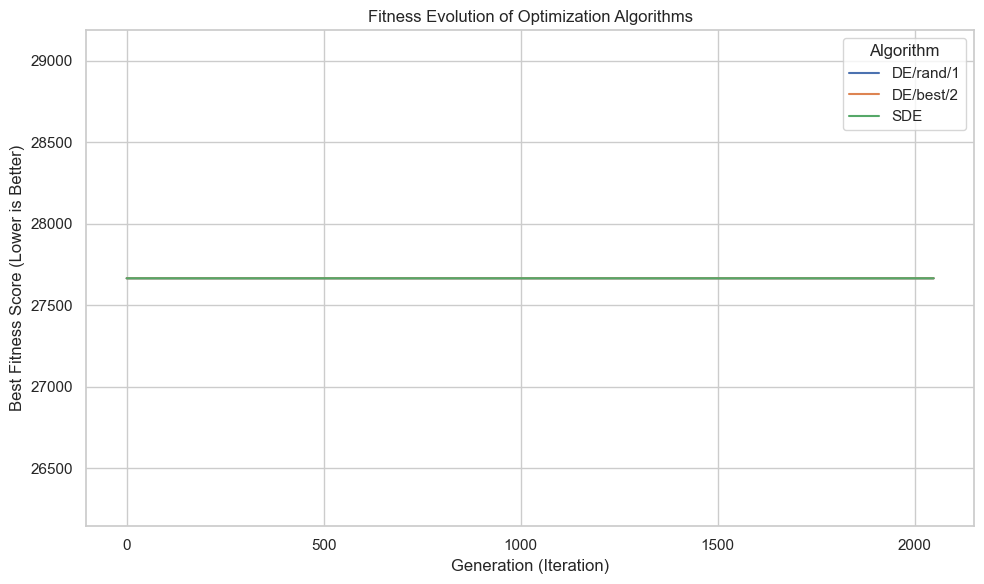

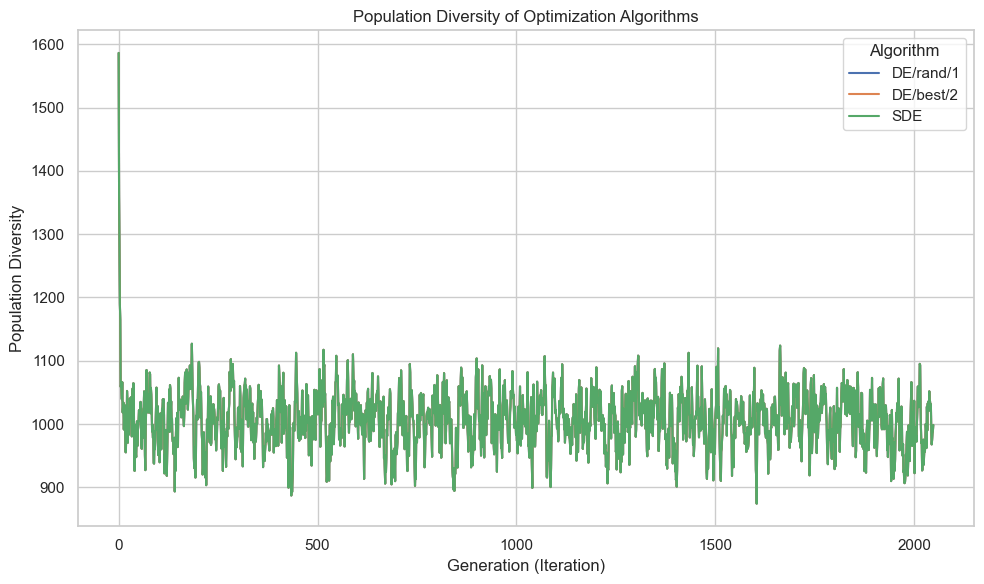

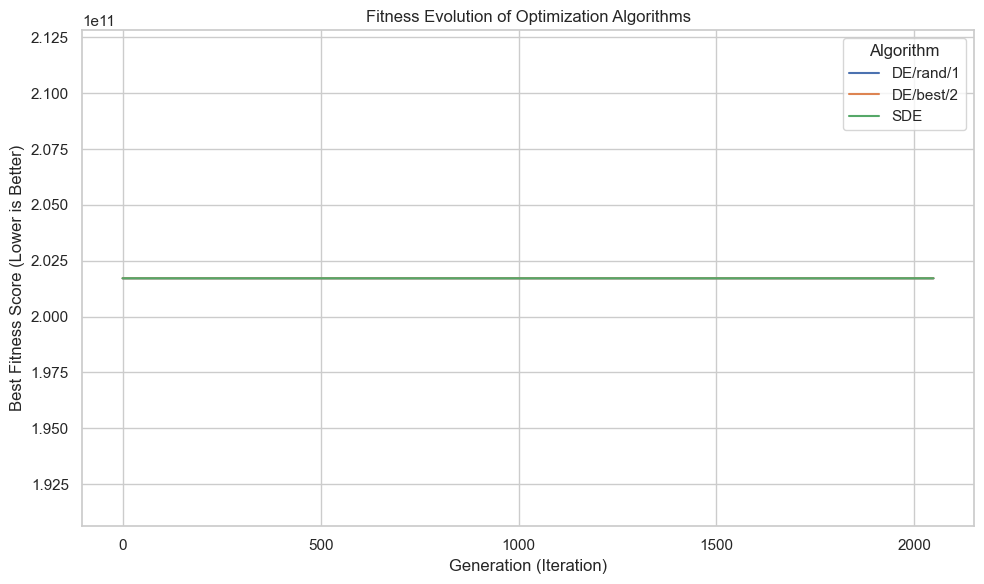

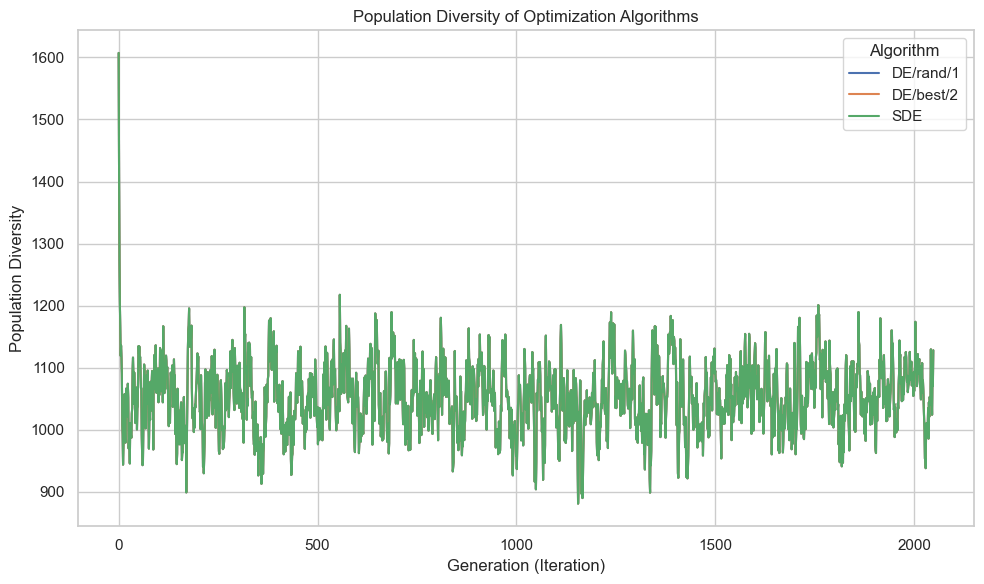

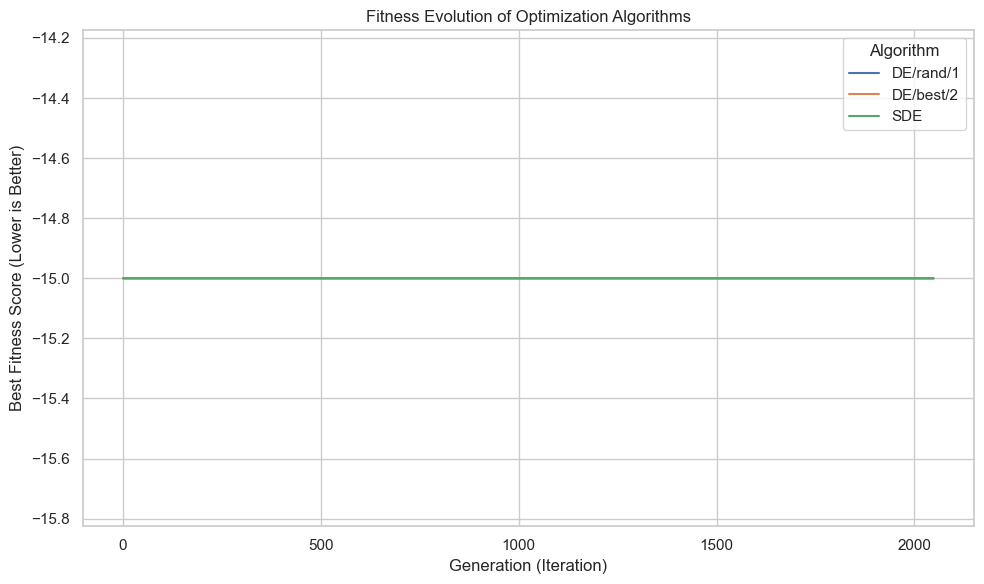

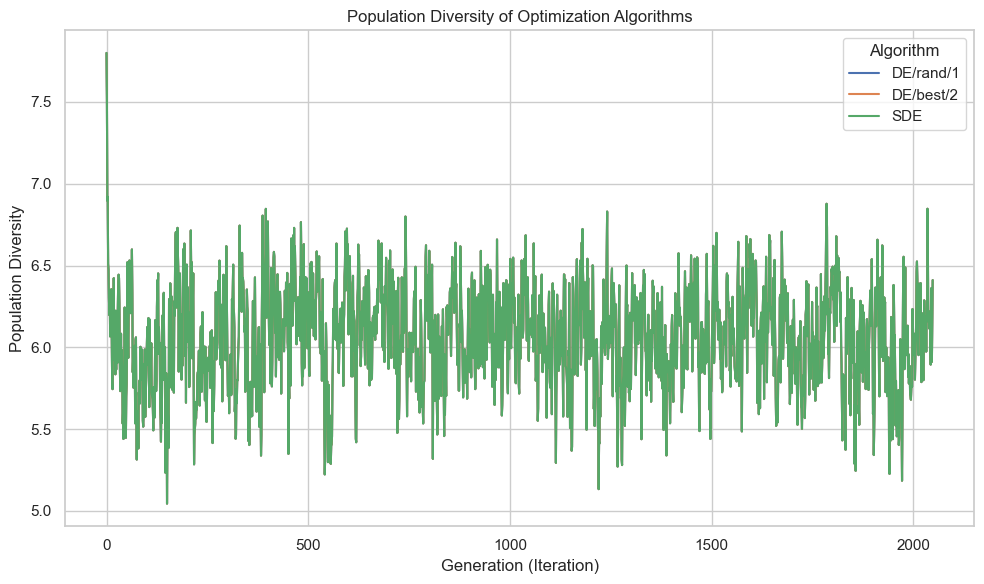

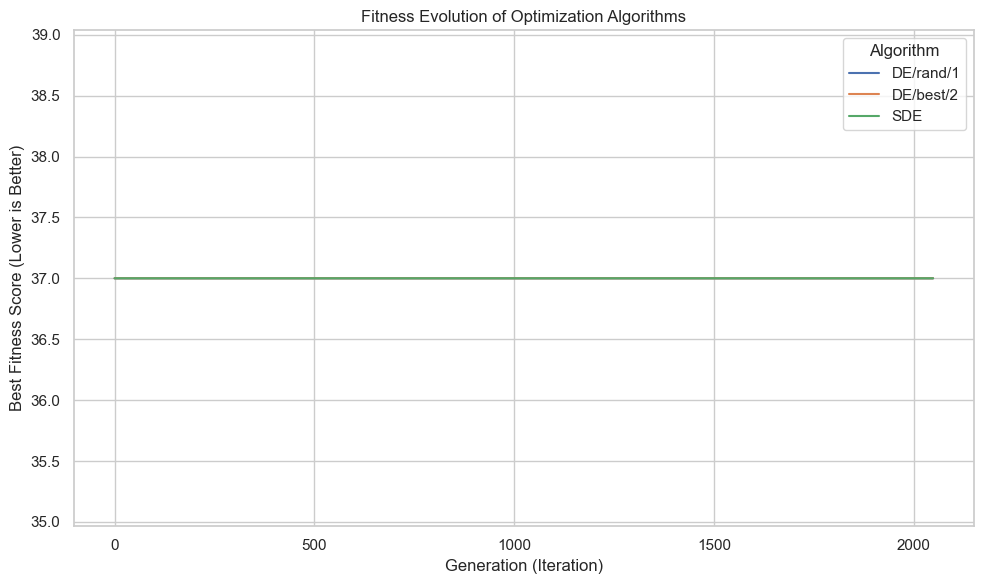

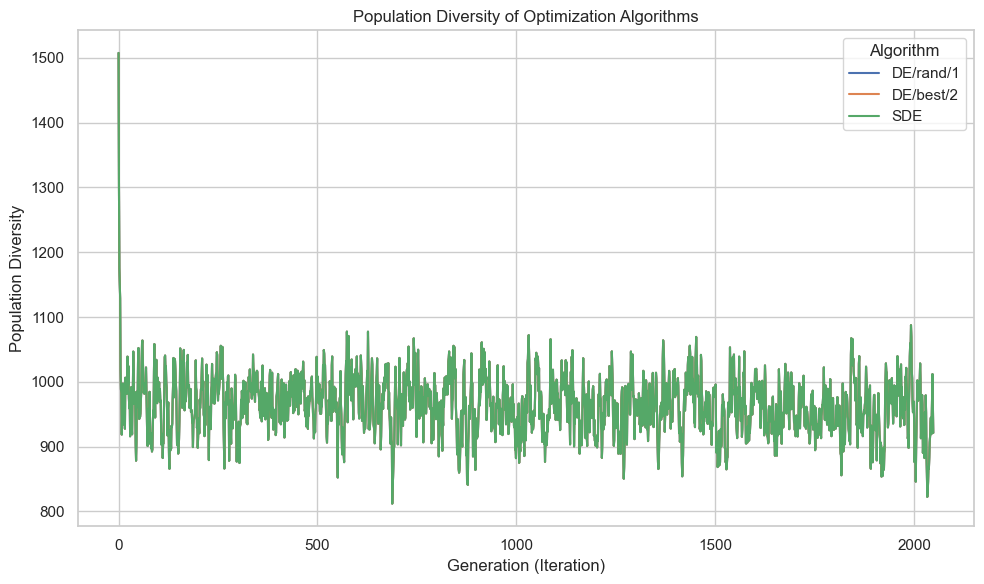

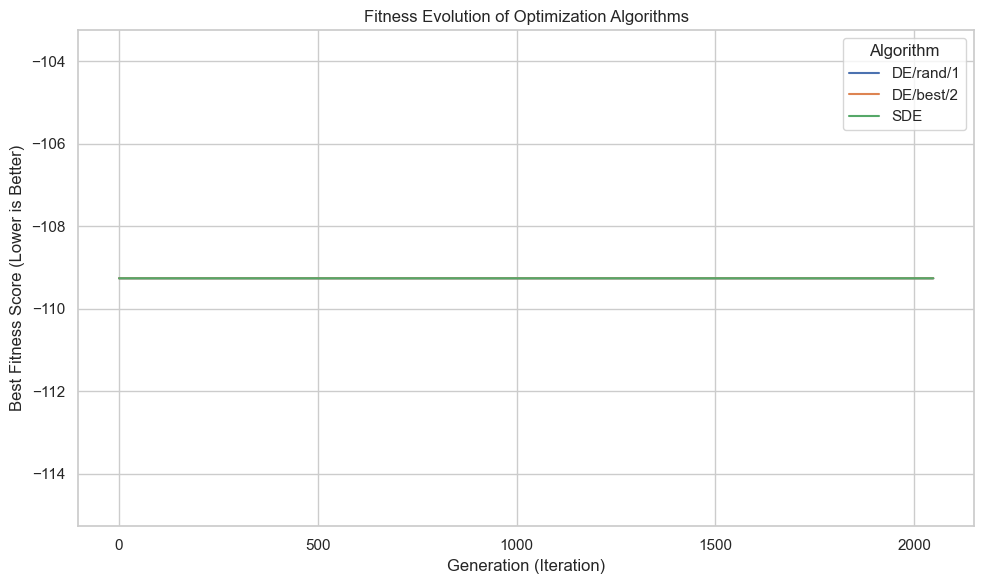

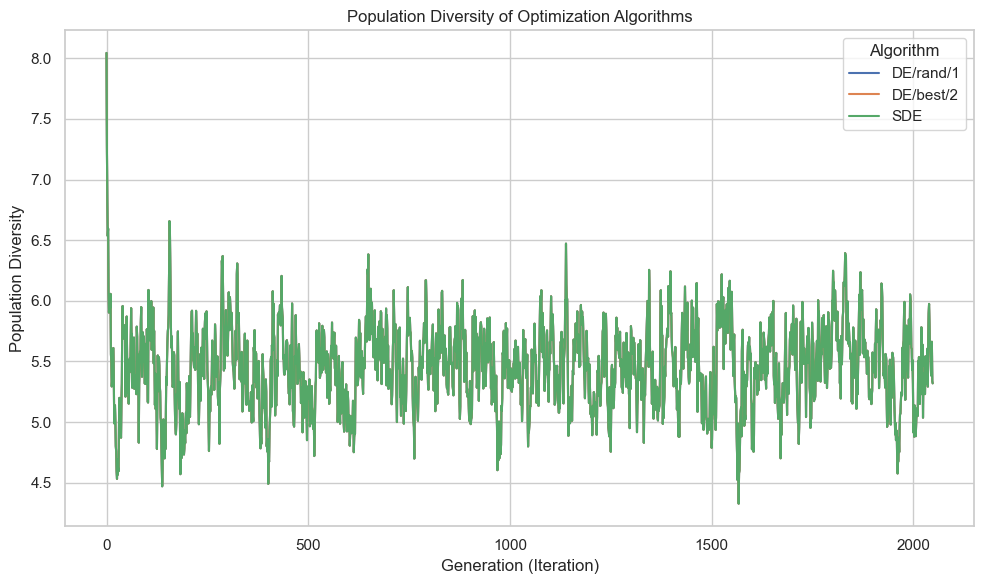

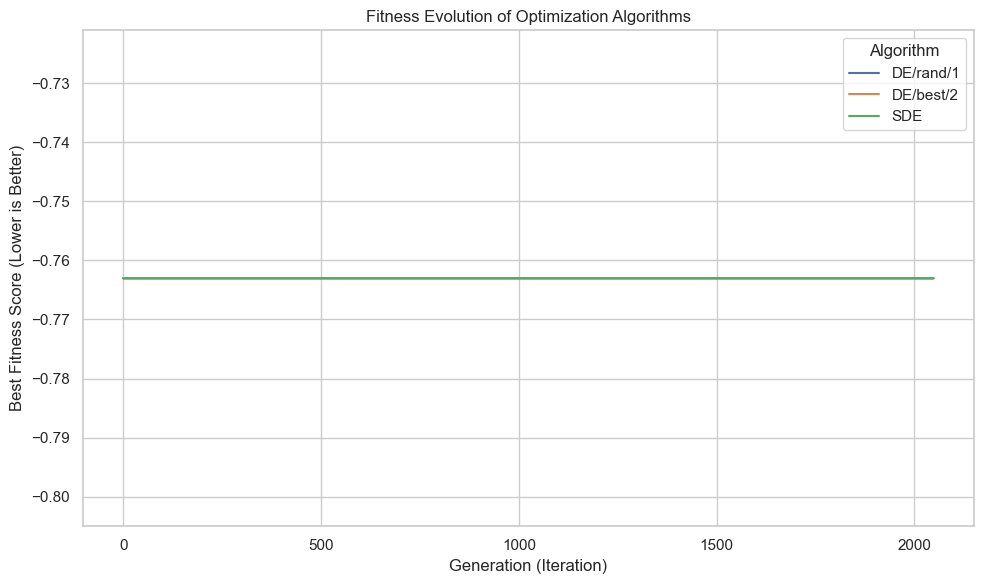

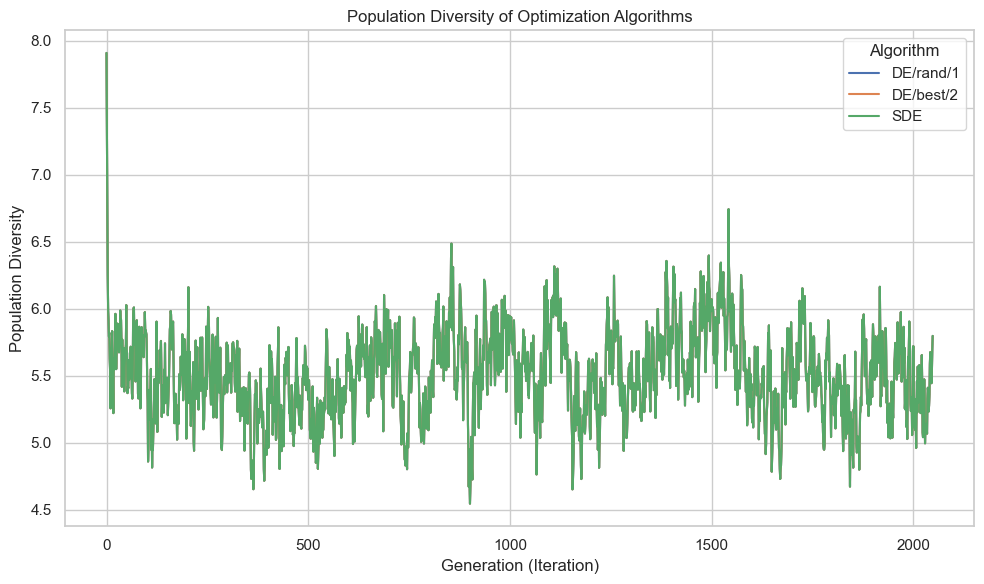

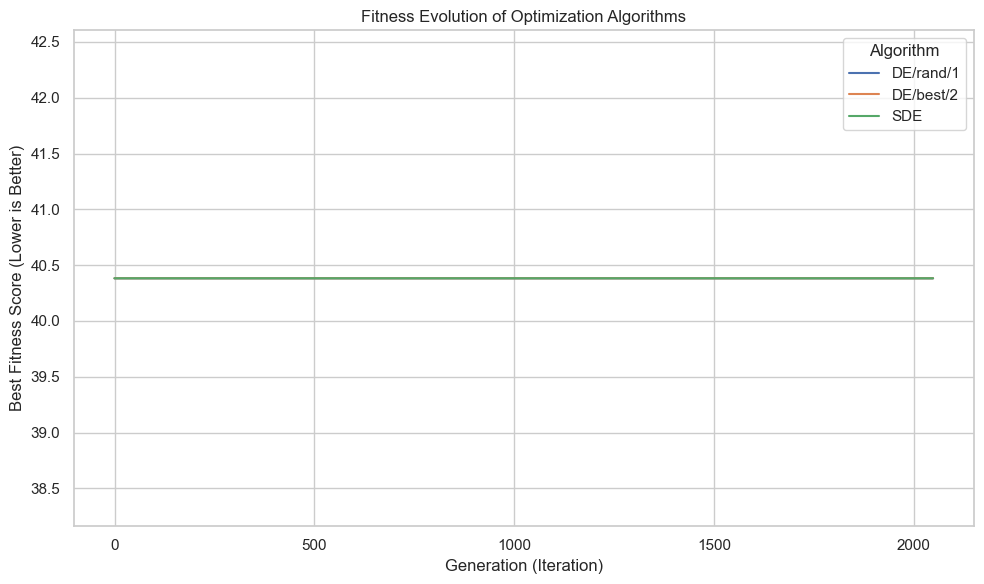

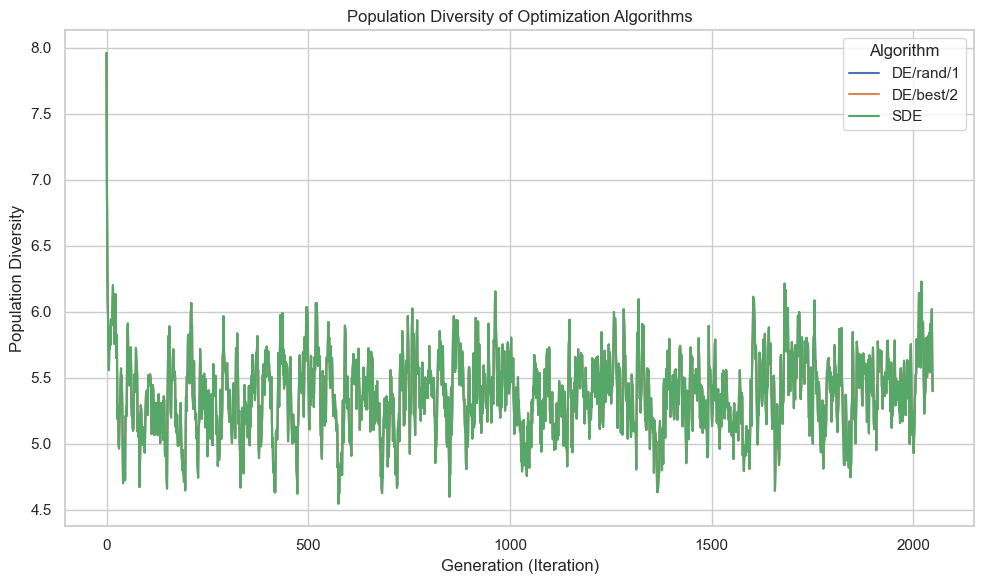

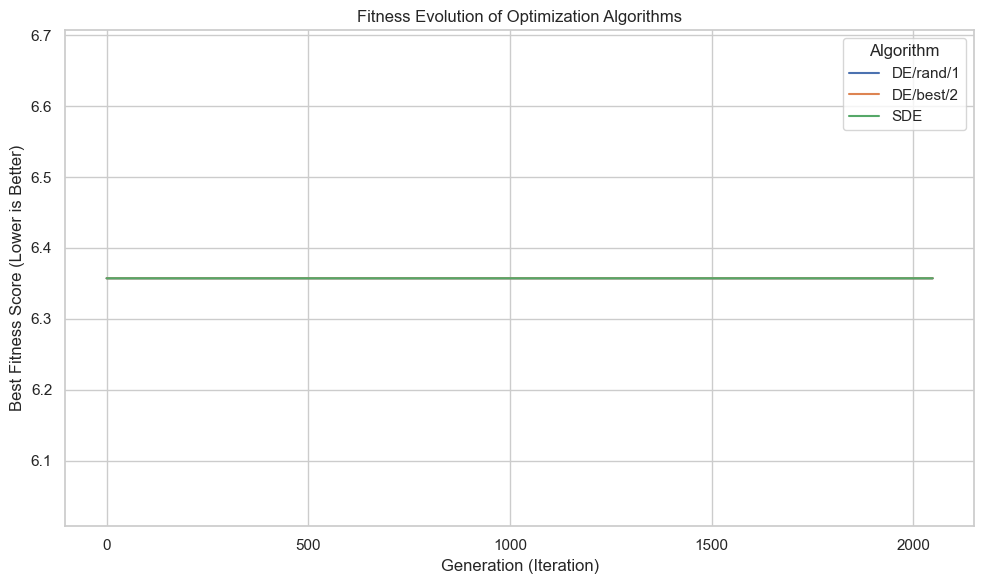

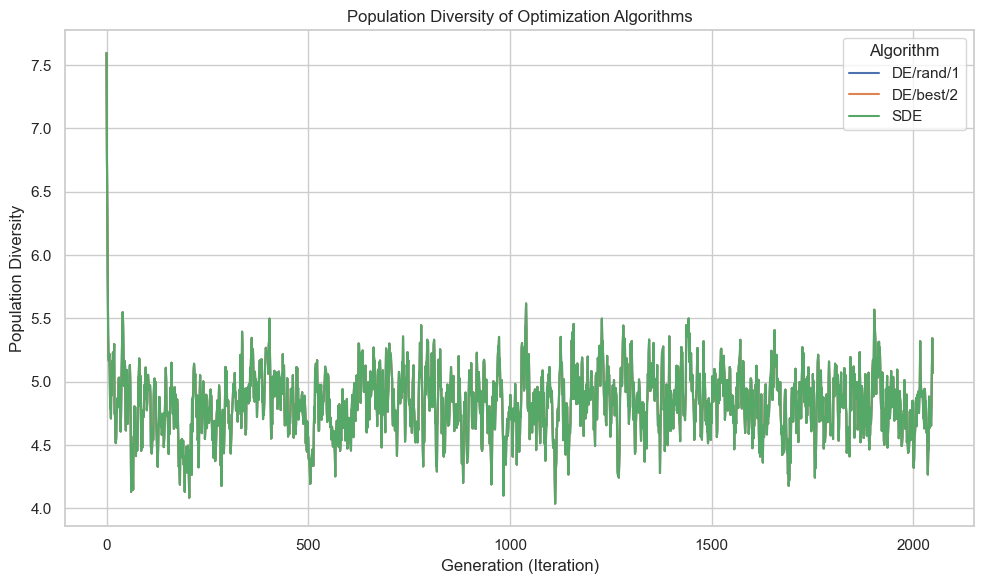

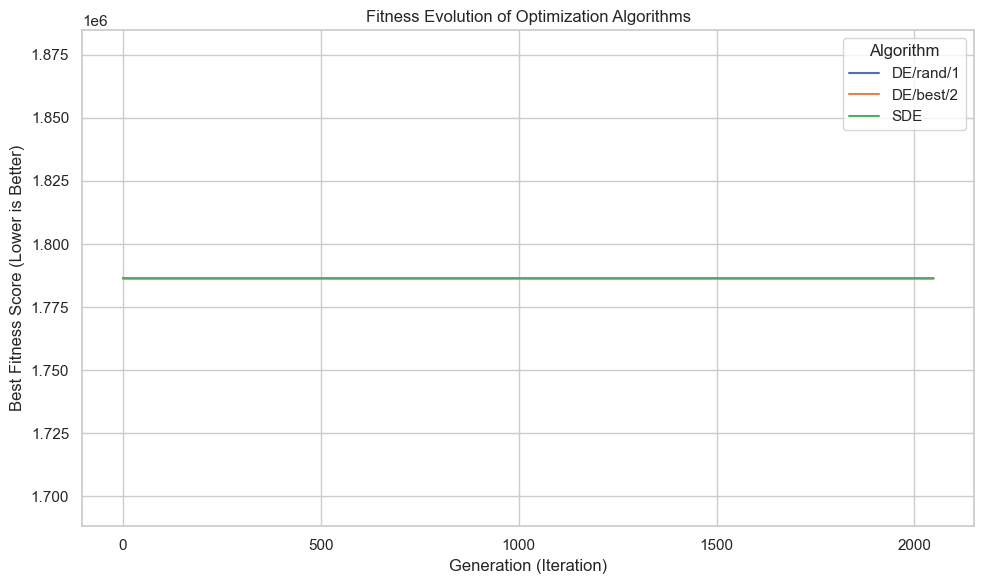

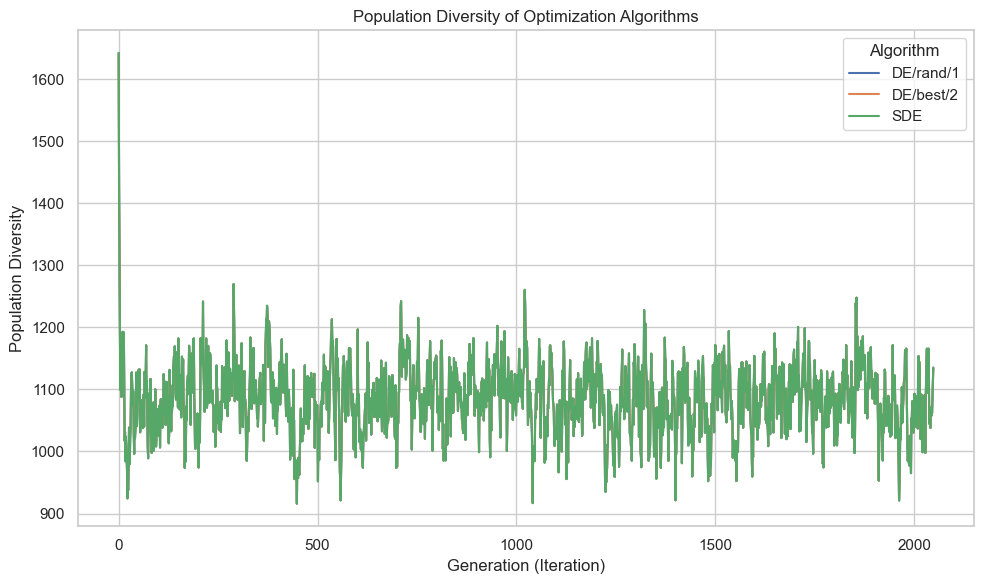

In [27]:
testbed = TestBed()
testbed.run_display()

Comparing with SciPy optimisation

In [ ]:
class SciPyTest:
    def __init__(self):
        self.tests = [Sphere, Rosenbrock, Step, Griewank, StyblinskiTang,
                      Shekel, Rastrigin, Ackley, RotatedElipsoid]
        self.results = []
    
    def run(self):
        for test in self.tests:
            x0 = [random.uniform(test.lower_bounds[0], test.upper_bounds[0]) for _ in range(N)]
            self.results.append(minimize(test.fun,
                                         x0,
                                         bounds=zip(test.lower_bounds,
                                                    test.upper_bounds)))
    
    def display_results(self):
        for test, result in zip(self.tests, self.results):
            print(f'for test {test.__name__} found {result.fun} in {result.nit} iter')

In [ ]:
refer = SciPyTest()
refer.run()
refer.display_results()

for test Sphere found 2.9107432636235024e-16 in 2 iter
for test Rosenbrock found 4.1393182291367366e-11 in 93 iter
for test Step found -12 in 0 iter
for test Griewank found 0.3494307558012508 in 26 iter
for test StyblinskiTang found -242.64573038770135 in 11 iter
for test Shekel found -1.285697185907486 in 21 iter
for test Rastrigin found 27.858742401993243 in 8 iter
for test Ackley found 8.302041088273434 in 9 iter
for test RotatedElipsoid found 1.415165889873553e-11 in 20 iter
